# Compute and Plot changes on B0, B1map and FlipAngle:
-------------------------------------------------------------

### Make MASKs & ROIs 
----------------------
Create anterior/mid and posterior ROIs, those will be 2.0 * voxel size * side 
MASKs are in dMRI space

In [1]:
import os 
import numpy as np 
import subprocess as sub 
import nibabel as nib
import matplotlib.pyplot as plt
import nilearn as nil 
from nilearn.image.image import mean_img #Estimate mean of a 4D volume --> mean_haxby = mean_img(func_filename)
from nilearn.plotting import plot_roi, show
from nilearn.maskers import NiftiMasker #Create a mask


home=r"/home/malberti/wks14/temp/FF_DWI_Drift"
derivatives=r"/home/malberti/wks14/temp/FF_DWI_Drift/derivatives"      

## ===============================================================================
# Try -MRI lsit 
# Asterix → dict  (was using [] instead of {})
Asterix = {
    "Asterix_c": ["sub-16_ses-01", "sub-17_ses-01", "sub-20_ses-01", "sub-21_ses-01", "sub-25_ses-01", "sub-26_ses-01", "sub-29_ses-01", "sub-30_ses-01","sub-32_ses-01"],
    "Asterix_w": ["sub-19_ses-13", "sub-18_ses-13", "sub-15_ses-13", "sub-22_ses-13", "sub-23_ses-13", "sub-24_ses-13", "sub-27_ses-13", "sub-28_ses-13", "sub-31_ses-13"],
   # "Asterix_w2": [
   # "sub-32_ses-02", "sub-32_ses-03", "sub-32_ses-04","sub-32_ses-05", "sub-32_ses-06",
  #  "sub-31_ses-14", "sub-31_ses-15", "sub-31_ses-16", "sub-31_ses-17", "sub-31_ses-18", "sub-31_ses-19", "sub-31_ses-20", "sub-31_ses-21", "sub-31_ses-22", "sub-31_ses-23", "sub-31_ses-24",
  #  "sub-30_ses-02", "sub-30_ses-03", "sub-30_ses-04","sub-30_ses-05", "sub-30_ses-06",
  #  "sub-29_ses-02", "sub-29_ses-03", "sub-29_ses-04",
  #  "sub-28_ses-14", "sub-28_ses-15", "sub-28_ses-16", "sub-28_ses-17", "sub-28_ses-18",
  #  "sub-27_ses-14", "sub-27_ses-15", "sub-27_ses-16", "sub-27_ses-17", "sub-27_ses-18", "sub-27_ses-19", "sub-27_ses-20", "sub-27_ses-21", "sub-27_ses-22", "sub-27_ses-23", "sub-27_ses-24",
  #  "sub-26_ses-02", "sub-26_ses-03", "sub-26_ses-04" ,"sub-26_ses-05" ,"sub-26_ses-06",   
  #  "sub-25_ses-02", "sub-25_ses-03",
  #  "sub-24_ses-14", "sub-24_ses-15", "sub-24_ses-16", "sub-24_ses-17", "sub-24_ses-18", "sub-24_ses-19", "sub-24_ses-20", 
  #  "sub-23_ses-14", "sub-23_ses-15", "sub-23_ses-16",
  #  "sub-22_ses-14", "sub-22_ses-15", "sub-22_ses-16", "sub-22_ses-17", "sub-22_ses-18", "sub-22_ses-19", "sub-22_ses-20",
  #  "sub-19_ses-14", "sub-19_ses-15", "sub-19_ses-16", "sub-19_ses-17",    # NUmber of scans on Asterix [13 --> 17]
  #  "sub-18_ses-14", "sub-18_ses-15", "sub-18_ses-16", "sub-18_ses-17", "sub-18_ses-18", "sub-18_ses-19",   # NUmber of scans on Asterix [13 --> 19]
  #  "sub-15_ses-14", "sub-15_ses-15", "sub-15_ses-16", "sub-15_ses-17", "sub-15_ses-18", "sub-15_ses-19", "sub-15_ses-20", "sub-15_ses-21" , "sub-15_ses-22" # NUmber of scans on Asterix [13 --> 22]
  #  ]
}

Obelix= {
    "Obelix_c" : ["sub-15_ses-01", "sub-18_ses-01","sub-19_ses-01", "sub-22_ses-01", "sub-23_ses-01", "sub-24_ses-01", "sub-27_ses-01", "sub-28_ses-01","sub-31_ses-01"], 
    "Obelix_w" : [
    "sub-31_ses-02", "sub-31_ses-03", "sub-31_ses-04", "sub-31_ses-05", "sub-31_ses-06", "sub-31_ses-07", "sub-31_ses-08", "sub-31_ses-09", "sub-31_ses-10", "sub-31_ses-11", "sub-31_ses-12",
    "sub-28_ses-02", "sub-28_ses-03", "sub-28_ses-04", "sub-28_ses-05", "sub-28_ses-06", "sub-28_ses-07", "sub-28_ses-08", "sub-28_ses-09", "sub-28_ses-10", "sub-28_ses-11", "sub-28_ses-12",
    "sub-27_ses-02", "sub-27_ses-03", "sub-27_ses-04", "sub-27_ses-05", "sub-27_ses-06", "sub-27_ses-07", "sub-27_ses-08", "sub-27_ses-09", "sub-27_ses-10", "sub-27_ses-11", "sub-27_ses-12",
    "sub-24_ses-02", "sub-24_ses-03", "sub-24_ses-04", "sub-24_ses-05", "sub-24_ses-06", "sub-24_ses-07", "sub-24_ses-08", "sub-24_ses-09", "sub-24_ses-10", "sub-24_ses-11", "sub-24_ses-12",
    "sub-23_ses-02", "sub-23_ses-03", "sub-23_ses-04", "sub-23_ses-05", "sub-23_ses-06", "sub-23_ses-07", "sub-23_ses-08", "sub-23_ses-09", "sub-23_ses-10", "sub-23_ses-11", "sub-23_ses-12",
    "sub-22_ses-02", "sub-22_ses-03", "sub-22_ses-04", "sub-22_ses-05", "sub-22_ses-06", "sub-22_ses-07", "sub-22_ses-08", "sub-22_ses-09", "sub-22_ses-10", "sub-22_ses-11", "sub-22_ses-12",
    "sub-19_ses-02", "sub-19_ses-03", "sub-19_ses-04", "sub-19_ses-05", "sub-19_ses-06", "sub-19_ses-07", "sub-19_ses-08", "sub-19_ses-09", "sub-19_ses-10", "sub-19_ses-11", "sub-19_ses-12",
    "sub-18_ses-02", "sub-18_ses-03", "sub-18_ses-04", "sub-18_ses-05", "sub-18_ses-06", "sub-18_ses-07", "sub-18_ses-08", "sub-18_ses-09", "sub-18_ses-10", "sub-18_ses-11", "sub-18_ses-12", 
    "sub-15_ses-02", "sub-15_ses-03", "sub-15_ses-04", "sub-15_ses-05", "sub-15_ses-06", "sub-15_ses-07", "sub-15_ses-08", "sub-15_ses-09", "sub-15_ses-10", "sub-15_ses-11", "sub-15_ses-12"  # NUmber of scans on Asterix [13 --> 22]
    ]
}

PHANTOMS= {
    "Asterix_c": ["sub-16_ses-01", "sub-17_ses-01", "sub-20_ses-01", "sub-21_ses-01", "sub-25_ses-01", "sub-26_ses-01", "sub-29_ses-01", "sub-30_ses-01","sub-32_ses-01"],
    "Asterix_w": ["sub-19_ses-13", "sub-18_ses-13", "sub-15_ses-13", "sub-22_ses-13", "sub-23_ses-13", "sub-24_ses-13", "sub-27_ses-13", "sub-28_ses-13", "sub-31_ses-13"],
    "Asterix_w2": [
    "sub-32_ses-02", "sub-32_ses-03", "sub-32_ses-04","sub-32_ses-05", "sub-32_ses-06",
    "sub-31_ses-14", "sub-31_ses-15", "sub-31_ses-16", "sub-31_ses-17", "sub-31_ses-18", "sub-31_ses-19", "sub-31_ses-20", "sub-31_ses-21", "sub-31_ses-22", "sub-31_ses-23", "sub-31_ses-24",
    "sub-30_ses-02", "sub-30_ses-03", "sub-30_ses-04","sub-30_ses-05", "sub-30_ses-06",
    "sub-29_ses-02", "sub-29_ses-03", "sub-29_ses-04",
    "sub-28_ses-14", "sub-28_ses-15", "sub-28_ses-16", "sub-28_ses-17", "sub-28_ses-18",
    "sub-27_ses-14", "sub-27_ses-15", "sub-27_ses-16", "sub-27_ses-17", "sub-27_ses-18", "sub-27_ses-19", "sub-27_ses-20", "sub-27_ses-21", "sub-27_ses-22", "sub-27_ses-23", "sub-27_ses-24",
    "sub-26_ses-02", "sub-26_ses-03", "sub-26_ses-04" ,"sub-26_ses-05" ,"sub-26_ses-06",   
    "sub-25_ses-02", "sub-25_ses-03",
    "sub-24_ses-14", "sub-24_ses-15", "sub-24_ses-16", "sub-24_ses-17", "sub-24_ses-18", "sub-24_ses-19", "sub-24_ses-20", 
    "sub-23_ses-14", "sub-23_ses-15", "sub-23_ses-16",
    "sub-22_ses-14", "sub-22_ses-15", "sub-22_ses-16", "sub-22_ses-17", "sub-22_ses-18", "sub-22_ses-19", "sub-22_ses-20",
    "sub-19_ses-14", "sub-19_ses-15", "sub-19_ses-16", "sub-19_ses-17",    # NUmber of scans on Asterix [13 --> 17]
    "sub-18_ses-14", "sub-18_ses-15", "sub-18_ses-16", "sub-18_ses-17", "sub-18_ses-18", "sub-18_ses-19",   # NUmber of scans on Asterix [13 --> 19]
    "sub-15_ses-14", "sub-15_ses-15", "sub-15_ses-16", "sub-15_ses-17", "sub-15_ses-18", "sub-15_ses-19", "sub-15_ses-20", "sub-15_ses-21" , "sub-15_ses-22"],
    "Obelix_c" : ["sub-15_ses-01", "sub-18_ses-01","sub-19_ses-01", "sub-22_ses-01", "sub-23_ses-01", "sub-24_ses-01", "sub-27_ses-01", "sub-28_ses-01","sub-31_ses-01"], 
    "Obelix_w" : [
    "sub-31_ses-02", "sub-31_ses-03", "sub-31_ses-04", "sub-31_ses-05", "sub-31_ses-06", "sub-31_ses-07", "sub-31_ses-08", "sub-31_ses-09", "sub-31_ses-10", "sub-31_ses-11", "sub-31_ses-12",
    "sub-28_ses-02", "sub-28_ses-03", "sub-28_ses-04", "sub-28_ses-05", "sub-28_ses-06", "sub-28_ses-07", "sub-28_ses-08", "sub-28_ses-09", "sub-28_ses-10", "sub-28_ses-11", "sub-28_ses-12",
    "sub-27_ses-02", "sub-27_ses-03", "sub-27_ses-04", "sub-27_ses-05", "sub-27_ses-06", "sub-27_ses-07", "sub-27_ses-08", "sub-27_ses-09", "sub-27_ses-10", "sub-27_ses-11", "sub-27_ses-12",
    "sub-24_ses-02", "sub-24_ses-03", "sub-24_ses-04", "sub-24_ses-05", "sub-24_ses-06", "sub-24_ses-07", "sub-24_ses-08", "sub-24_ses-09", "sub-24_ses-10", "sub-24_ses-11", "sub-24_ses-12",
    "sub-23_ses-02", "sub-23_ses-03", "sub-23_ses-04", "sub-23_ses-05", "sub-23_ses-06", "sub-23_ses-07", "sub-23_ses-08", "sub-23_ses-09", "sub-23_ses-10", "sub-23_ses-11", "sub-23_ses-12",
    "sub-22_ses-02", "sub-22_ses-03", "sub-22_ses-04", "sub-22_ses-05", "sub-22_ses-06", "sub-22_ses-07", "sub-22_ses-08", "sub-22_ses-09", "sub-22_ses-10", "sub-22_ses-11", "sub-22_ses-12",
    "sub-19_ses-02", "sub-19_ses-03", "sub-19_ses-04", "sub-19_ses-05", "sub-19_ses-06", "sub-19_ses-07", "sub-19_ses-08", "sub-19_ses-09", "sub-19_ses-10", "sub-19_ses-11", "sub-19_ses-12",
    "sub-18_ses-02", "sub-18_ses-03", "sub-18_ses-04", "sub-18_ses-05", "sub-18_ses-06", "sub-18_ses-07", "sub-18_ses-08", "sub-18_ses-09", "sub-18_ses-10", "sub-18_ses-11", "sub-18_ses-12", 
    "sub-15_ses-02", "sub-15_ses-03", "sub-15_ses-04", "sub-15_ses-05", "sub-15_ses-06", "sub-15_ses-07", "sub-15_ses-08", "sub-15_ses-09", "sub-15_ses-10", "sub-15_ses-11", "sub-15_ses-12"  # NUmber of scans on Asterix [13 --> 22]
    ]
}
    

### MASKs starting sizes 
----------------------------------
#### FLIP ANGLE: 
 starts = {
        "ant": ( #orange
            x_center  + offsets["ant"]["dx"],  # Cor/Sag x +15 | y - 10 | z + 0
            y_center -5 +offsets["ant"]["dy"], # Tra x +0 | y - 5 | z + 0
            z_center + offsets["ant"]["dz"],
        ),
        "mid": ( #Yellow
            x_center + offsets["mid"]["dx"],  # Cor/Sag x + 0  | y - 20 | z + 0
            y_center  -30+ offsets["mid"]["dy"], # Tra x +0 | y - 30 | z + 0
            z_center   + offsets["mid"]["dz"],
        ),
        "post": ( # Magenta
            x_center + offsets["post"]["dx"],  # Cor/Sag x - 15 | y + 0 | z + 0
            y_center - 12 + offsets["post"]["dy"], # Tra x +0 | y - 12 | z + 0
            z_center + offsets["post"]["dz"],
        ),
    }

#### B1 map: 



In [ ]:
import os
import subprocess
import numpy as np
import nibabel as nib

# ===========================================================================
# CONFIGURATION
# ===========================================================================
PANORAMIX         = "/home/malberti/Unix_Folders/Asterix_Obelix_Population_Template/Panoramix_Template_Tmean.nii"
DEFAULT_CUBE_SIZE = (10, 10, 10)
DEFAULT_OFFSETS   = {
    "ant":  {"dx": 0, "dy": 20,  "dz":  5},
    "mid":  {"dx": 0, "dy": 13,  "dz": -15},
    "post": {"dx": 0, "dy": 11,  "dz":  5},
}


# ===========================================================================
# HELPERS
# ===========================================================================
def make_2d_affine(img):
    """
    Return a valid 4x4 affine for a 2D NIfTI slice.
    If the z-column is zero (degenerate 2D affine), replace it with the
    unit normal to the image plane (cross-product of x and y axes), scaled
    to 1 mm, so the matrix stays invertible and all outputs share one space.
    """
    A = img.affine.copy()
    if np.allclose(A[:3, 2], 0):
        normal = np.cross(A[:3, 0], A[:3, 1])
        norm   = np.linalg.norm(normal)
        if norm > 0:
            A[:3, 2] = normal / norm
    return A


def make_2d_header(img):
    """Return a header with non-zero pixdim[3] (z voxel size)."""
    h = img.header.copy()
    if h['pixdim'][3] == 0:
        h['pixdim'][3] = 1.0
    return h


def save_nifti(data, affine, header, path):
    """Save a NIfTI, enforcing consistent qform/sform."""
    img = nib.Nifti1Image(data.astype(np.uint8), affine, header)
    img.set_qform(affine, code=1)
    img.set_sform(affine, code=1)
    nib.save(img, path)


def build_masks(mask, offsets, cube_size):

    original_2d = False

    if mask.ndim == 2:
        original_2d = True
        mask = mask[:, :, np.newaxis]

    X, Y, Z = mask.shape

    if original_2d:
        px, py = cube_size[:2]
        pz = 1
    else:
        px, py, pz = cube_size

    x_center = X // 2 - px // 2
    y_center = Y // 2 - py // 2
    z_center = Z // 2 - pz // 2

   
    starts = {
        "ant": ( #orange
            x_center  + offsets["ant"]["dx"],  # Cor/Sag x +15 | y - 10 | z + 0
            y_center -5 +offsets["ant"]["dy"], # Tra x +0 | y - 5 | z + 0
            z_center + offsets["ant"]["dz"],
        ),
        "mid": ( #Yellow
            x_center + offsets["mid"]["dx"],  # Cor/Sag x + 0  | y - 20 | z + 0
            y_center  -30+ offsets["mid"]["dy"], # Tra x +0 | y - 30 | z + 0
            z_center   + offsets["mid"]["dz"],
        ),
        "post": ( # Magenta
            x_center + offsets["post"]["dx"],  # Cor/Sag x - 15 | y + 0 | z + 0
            y_center - 12 + offsets["post"]["dy"], # Tra x +0 | y - 12 | z + 0
            z_center + offsets["post"]["dz"],
        ),
    }
    """
    starts = {
        "ant": ( #orange
            x_center + 15 + offsets["ant"]["dx"],  # Cor/Sag x +15 | y - 10 | z + 0
            y_center - 10  +offsets["ant"]["dy"], # Tra x +0 | y - 5 | z + 0
            z_center + offsets["ant"]["dz"],
        ),
        "mid": ( #Yellow
            x_center + offsets["mid"]["dx"],  # Cor/Sag x + 0  | y - 20 | z + 0
            y_center  -20 + offsets["mid"]["dy"], # Tra x +0 | y - 30 | z + 0
            z_center   + offsets["mid"]["dz"],
        ),
        "post": ( # Magenta
            x_center -15 + offsets["post"]["dx"],  # Cor/Sag x - 15 | y + 0 | z + 0
            y_center  + offsets["post"]["dy"], # Tra x +0 | y - 12 | z + 0
            z_center + offsets["post"]["dz"],
        ),
    }
    """ 
    masks = {}

    for name, (xs, ys, zs) in starts.items():

        roi = np.zeros_like(mask, dtype=np.uint8)

        # clamp indices to valid range
        xs = max(0, min(xs, X - px))
        ys = max(0, min(ys, Y - py))
        zs = max(0, min(zs, Z - pz))

        roi[xs:xs + px, ys:ys + py, zs:zs + pz] = 1

        if original_2d:
            roi = roi[:, :, 0]

        masks[name] = roi

    return masks, starts


def save_tmp_masks(masks, affine, header, tmp_dir):
    os.makedirs(tmp_dir, exist_ok=True)
    paths = {}
    for key, arr in masks.items():
        if arr.ndim == 2:
            arr = arr[:, :, np.newaxis]
        path = os.path.join(tmp_dir, f"_tmp_cube_{key}.nii.gz")
        save_nifti(arr, affine, header, path)
        paths[key] = path
    return paths


def open_fsleyes(ref_path, mask_paths):
    cmd = [
        "fsleyes",
        ref_path,           "-cm", "greyscale",
        mask_paths["ant"],  "-cm", "copper",
        mask_paths["mid"],  "-cm", "red-yellow",
        mask_paths["post"], "-cm", "cool",
    ]
    print("\n  Opening FSLeyes … close the window when done.\n")
    subprocess.run(cmd)


# ===========================================================================
# MAIN LOOP
# ===========================================================================
label_map = {"ant": "anterior", "mid": "mid", "post": "posterior"}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses = subjid.split("_", 1)
        base    = os.path.join(home, "derivatives", pid, ses, "twix")
        tmp_dir = os.path.join(base, "tmp")
        os.makedirs(base,    exist_ok=True)
        os.makedirs(tmp_dir, exist_ok=True)

        #alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_tfl_map-tra_*_alpha.nii*"))) # Flip angle
        alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_tfl_map-cor_*_b1.nii*"))) #Trasmit eff. map dB0.nii
        if len(alpha_files) == 0:
            print(f"WARNING: no tfl_map-cor alpha files for {subjid}")
            continue

        for map_IMG in alpha_files:
            print(f"\nProcessing: {map_IMG}")

            img  = nib.load(map_IMG)
            data = img.get_fdata()

            # ── build consistent affine/header for all 2D outputs ─────
            affine = make_2d_affine(img)
            header = make_2d_header(img)

            # ── binary mask ───────────────────────────────────────────
            mask     = ((data > 0) & (data < 110)).astype(np.uint8)
            mask_out = mask[:, :, np.newaxis] if mask.ndim == 2 else mask
            save_nifti(mask_out, affine, header, mask_IMG)
            #print(f"Saved: {mask_IMG}")

            # ── greyscale reference for FSLeyes ───────────────────────
            ref_tmp_path = os.path.join(tmp_dir, f"_tmp_ref_{subjid}.nii.gz")
            ref_data     = data[:, :, np.newaxis] if data.ndim == 2 else data
            img_ref      = nib.Nifti1Image(ref_data, affine, header)
            img_ref.set_qform(affine, code=1)
            img_ref.set_sform(affine, code=1)
            nib.save(img_ref, ref_tmp_path)

            # ── ROI loop ──────────────────────────────────────────────
            offsets   = {k: dict(v) for k, v in DEFAULT_OFFSETS.items()}
            cube_size = DEFAULT_CUBE_SIZE
            approved  = False

            print(f"\n{'='*60}")
            print(f"  Subject: {subjid}")
            print(f"{'='*60}")

            while not approved:
                masks, starts = build_masks(mask, offsets, cube_size)
                mask_paths    = save_tmp_masks(masks, affine, header, tmp_dir)

                print("\n  Current ROI starts (voxel coords):")
                for roi, s in starts.items():
                    print(f"    {roi:4s}  x={s[0]:4d}  y={s[1]:4d}  z={s[2]:4d}")

                #open_fsleyes(ref_tmp_path, mask_paths)
                approved = True
            # ── save final masks ──────────────────────────────────────
            for key, arr in masks.items():
                arr_out = arr[:, :, np.newaxis] if arr.ndim == 2 else arr
                fname   = f"{subjid}_tfl-cor_MASK_{label_map[key]}_b1.nii.gz"
                save_nifti(arr_out, affine, header, os.path.join(base, fname))
                print(f"  Saved → {fname}")

            # ── clean up tmp ──────────────────────────────────────────
            for p in mask_paths.values():
                os.remove(p)
            os.remove(ref_tmp_path)

            print(f"\n  ✓ {subjid} done.\n")

## PLOT HISTs of FLIP ANGLE
-------------------------------------

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


[SKIP] no valid alpha files for sub-25_ses-01


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


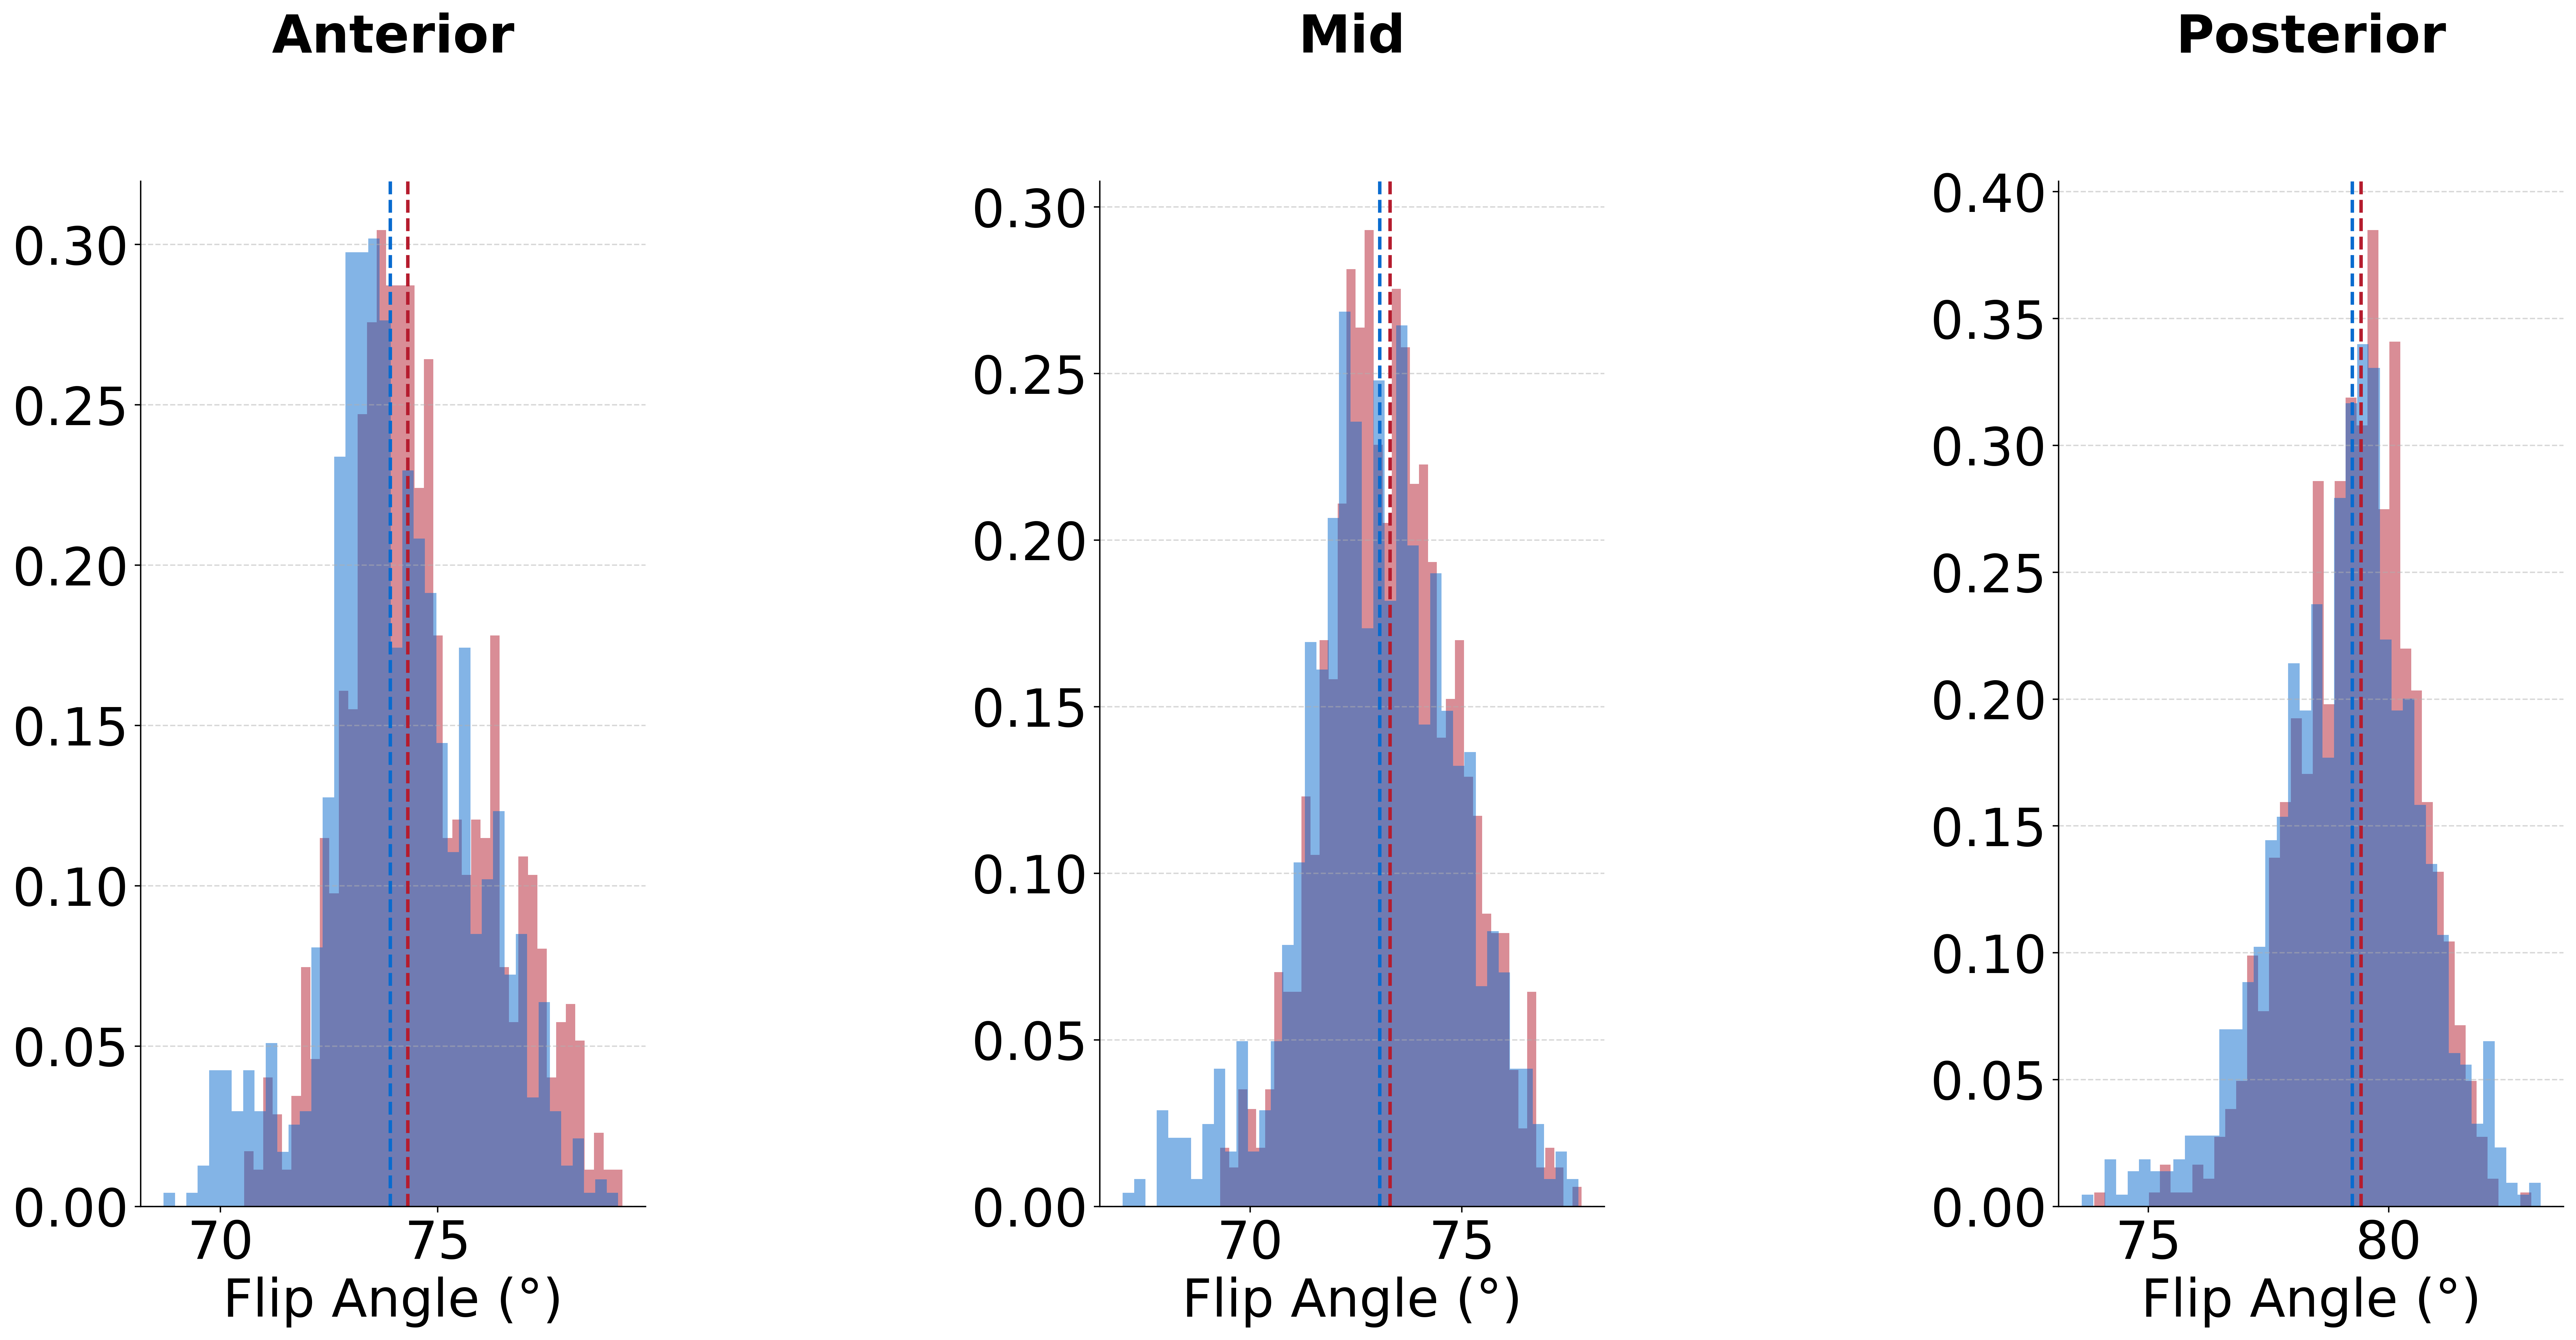

In [397]:
import glob, re
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
AXES="tra"
REGIONS = {
    "Anterior":  "tfl-cor_MASK_anterior",
    "Mid":       "tfl-cor_MASK_mid",
    "Posterior": "tfl-cor_MASK_posterior",
}
REGIONS = {
    "Anterior":  "tfl-tra_MASK_anterior",
    "Mid":       "tfl-tra_MASK_mid",
    "Posterior": "tfl-tra_MASK_posterior",
}


REGION_COLORS = {
    "Anterior":  {"Asterix_c": "#058E4A", "Asterix_w": "#43C57E"},
    "Mid":       {"Asterix_c": "#B51C2E", "Asterix_w": "#E6906C"},
    "Posterior": {"Asterix_c": "#086BCF", "Asterix_w": "#6ABAE2"},
}


# ─────────────────────────────────────────────────────────────────
# COLLECT — stack all voxels per condition × ROI
# ─────────────────────────────────────────────────────────────────
all_voxels = {
    region: {"Asterix_c": [], "Asterix_w": []}
    for region in REGIONS
}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses = subjid.split("_", 1)
        base = os.path.join(home, "derivatives", pid, ses, "twix")

        alpha_files = sorted(glob.glob(
            os.path.join(base, f"{subjid}_tfl_map-{AXES}_*alpha*.nii*")
        ))
        alpha_files = [
            f for f in alpha_files
            if "_MASK" not in os.path.basename(f)
            and (m := re.search(r"_(\d+(?:[p\.]\d+)?)_alpha", os.path.basename(f)))
            and float(m.group(1).replace("p", ".")) > 280
        ]

        if len(alpha_files) == 0:
            print(f"[SKIP] no valid alpha files for {subjid}")
            continue

        for map_IMG in alpha_files:
            img  = nib.load(map_IMG).get_fdata()
            data = img[:, :, 0] if img.ndim == 3 else img

            for region, mask_stem in REGIONS.items():
                mask_path = os.path.join(base, f"{subjid}_{mask_stem}.nii.gz")
                if not os.path.exists(mask_path):
                    continue
                mask_data = nib.load(mask_path).get_fdata()
                mask_2d   = mask_data[:, :, 0] if mask_data.ndim == 3 else mask_data

                vals = data[mask_2d.astype(bool)]
                vals = vals[(vals > 0) & (vals < 110)]
                all_voxels[region][condition].extend(vals.tolist())

# ─────────────────────────────────────────────────────────────────
# PLOT — 3 panels, 2 overlapping histograms per panel
# ─────────────────────────────────────────────────────────────────
HIST_COLORS = {
    "Asterix_c": ("#B51C2E", "Idle"),
    "Asterix_w": ("#086BCF", "Running"),
}

fig, axes = plt.subplots(1, 3, figsize=(25, 10), dpi=400,
                         facecolor="white")

for ax, region in zip(axes, REGIONS):
    for cond, (col, label) in HIST_COLORS.items():
        vals = np.array(all_voxels[region][cond])
      
        ax.hist(vals, bins=40, color=col, alpha=0.5,
                label=f"{label}",
                density=True, edgecolor="none")
        
        ax.axvline(np.median(vals), color=col, linewidth=2,linestyle="--", label=f"median={np.median(vals):.1f}°")

    # t-test on voxel distributions
    v0 = np.array(all_voxels[region]["Asterix_c"])
    v1 = np.array(all_voxels[region]["Asterix_w"])
    if len(v0) > 1 and len(v1) > 1:
        _, p = stats.ttest_ind(v0, v1, equal_var=True)
        sig     = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        p_label = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.set_title(f"{region}\n\n", fontsize=30, fontweight="bold")
    else:
        ax.set_title(region, fontsize=30, fontweight="bold")

    ax.set_xlabel("Flip Angle (°)", fontsize=30)
    ax.set_ylabel("",        fontsize=30)
    ax.tick_params(axis='y', labelsize=30)    
    ax.tick_params(axis='x', labelsize=30)    

  #  ax.legend(fontsize=30, loc='upper center', bbox_to_anchor=(0.5, -0.15),  frameon=False)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.subplots_adjust(top=0.93, hspace=0.55, wspace=0.9)
plt.show()


## PLOTs HISTS of trasmit efficency 
---------------------------------------------

In [ ]:
import glob, re
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
AXES="tra"
REGIONS = {
    "Anterior":  "tfl-cor_MASK_anterior",
    "Mid":       "tfl-cor_MASK_mid",
    "Posterior": "tfl-cor_MASK_posterior",
}

REGIONS = {
    "Anterior":  "tfl-tra_MASK_anterior",
    "Mid":       "tfl-tra_MASK_mid",
    "Posterior": "tfl-tra_MASK_posterior",
}


REGION_COLORS = {
    "Anterior":  {"Asterix_c": "#058E4A", "Asterix_w": "#43C57E"},
    "Mid":       {"Asterix_c": "#B51C2E", "Asterix_w": "#E6906C"},
    "Posterior": {"Asterix_c": "#086BCF", "Asterix_w": "#6ABAE2"},
}

MAP="nT_per_V"
# ─────────────────────────────────────────────────────────────────
# COLLECT — stack all voxels per condition × ROI
# ─────────────────────────────────────────────────────────────────
all_voxels = {
    region: {"Asterix_c": [], "Asterix_w": []}
    for region in REGIONS
}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses = subjid.split("_", 1)
        base = os.path.join(home, "derivatives", pid, ses, "twix")

        alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_tfl_map-{AXES}_*_{MAP}.nii")))
        print(alpha_files)

        alpha_files = [
            f for f in alpha_files
            if "_MASK" not in os.path.basename(f)
            and (m := re.search(r"_(\d+(?:[p\.]\d+)?)_nT_per_V", os.path.basename(f)))
            and float(m.group(1).replace("p", ".")) > 280
        ]

        if len(alpha_files) == 0:
            print(alpha_files)
            print(f"[SKIP] no valid alpha files for {subjid}")
            continue

        for map_IMG in alpha_files:
            img  = nib.load(map_IMG).get_fdata()
            data = img[:, :, 0] if img.ndim == 3 else img

            for region, mask_stem in REGIONS.items():
                mask_path = os.path.join(base, f"{subjid}_{mask_stem}_nT_per_V.nii.gz")
                if not os.path.exists(mask_path):
                    continue
                mask_data = nib.load(mask_path).get_fdata()
                mask_2d   = mask_data[:, :, 0] if mask_data.ndim == 3 else mask_data

                vals = data[mask_2d.astype(bool)]
                vals = vals[(vals > 0) & (vals < 110)]
                all_voxels[region][condition].extend(vals.tolist())

# ─────────────────────────────────────────────────────────────────
# PLOT — 3 panels, 2 overlapping histograms per panel
# ─────────────────────────────────────────────────────────────────
HIST_COLORS = {
    "Asterix_c": ("#B51C2E", "Idle"),
    "Asterix_w": ("#086BCF", "Running"),
}

fig, axes = plt.subplots(1, 3, figsize=(25, 7), dpi=400,
                         facecolor="white")

for ax, region in zip(axes, REGIONS):
    for cond, (col, label) in HIST_COLORS.items():
        vals = np.array(all_voxels[region][cond])
      
        ax.hist(vals, bins=40, color=col, alpha=0.5,
                label=f"{label}  (n={len(vals)})",
                density=True, edgecolor="none")

        # vertical mean line
       # ax.axvline(vals.mean(), color=col, linewidth=2,
       #            linestyle="--", label=f"{label} mean={vals.mean():.1f}°")
        
        ax.axvline(np.median(vals), color=col, linewidth=2,
                   linestyle="solid", label=f"{label} median={np.median(vals):.1f}°")

    # t-test on voxel distributions
    v0 = np.array(all_voxels[region]["Asterix_c"])
    v1 = np.array(all_voxels[region]["Asterix_w"])
    if len(v0) > 1 and len(v1) > 1:
        _, p = stats.ttest_ind(v0, v1, equal_var=True)
        sig     = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        p_label = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.set_title(f"{region}\n\n", fontsize=22,
                     fontweight="bold")
    else:
        ax.set_title(region, fontsize=22, fontweight="bold")

    ax.set_xlabel("Trasmit Efficiency", fontsize=20)
    ax.set_ylabel("Density",        fontsize=20)
    ax.tick_params(labelsize=18)
    ax.legend(fontsize=14, loc='upper center', bbox_to_anchor=(0.5, -0.15))
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()


## PLOTs HISTs of B1 map
----------------------------
B1map are way to much dishomogenous within the same scan 

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


[SKIP] no valid alpha files for sub-25_ses-01


pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


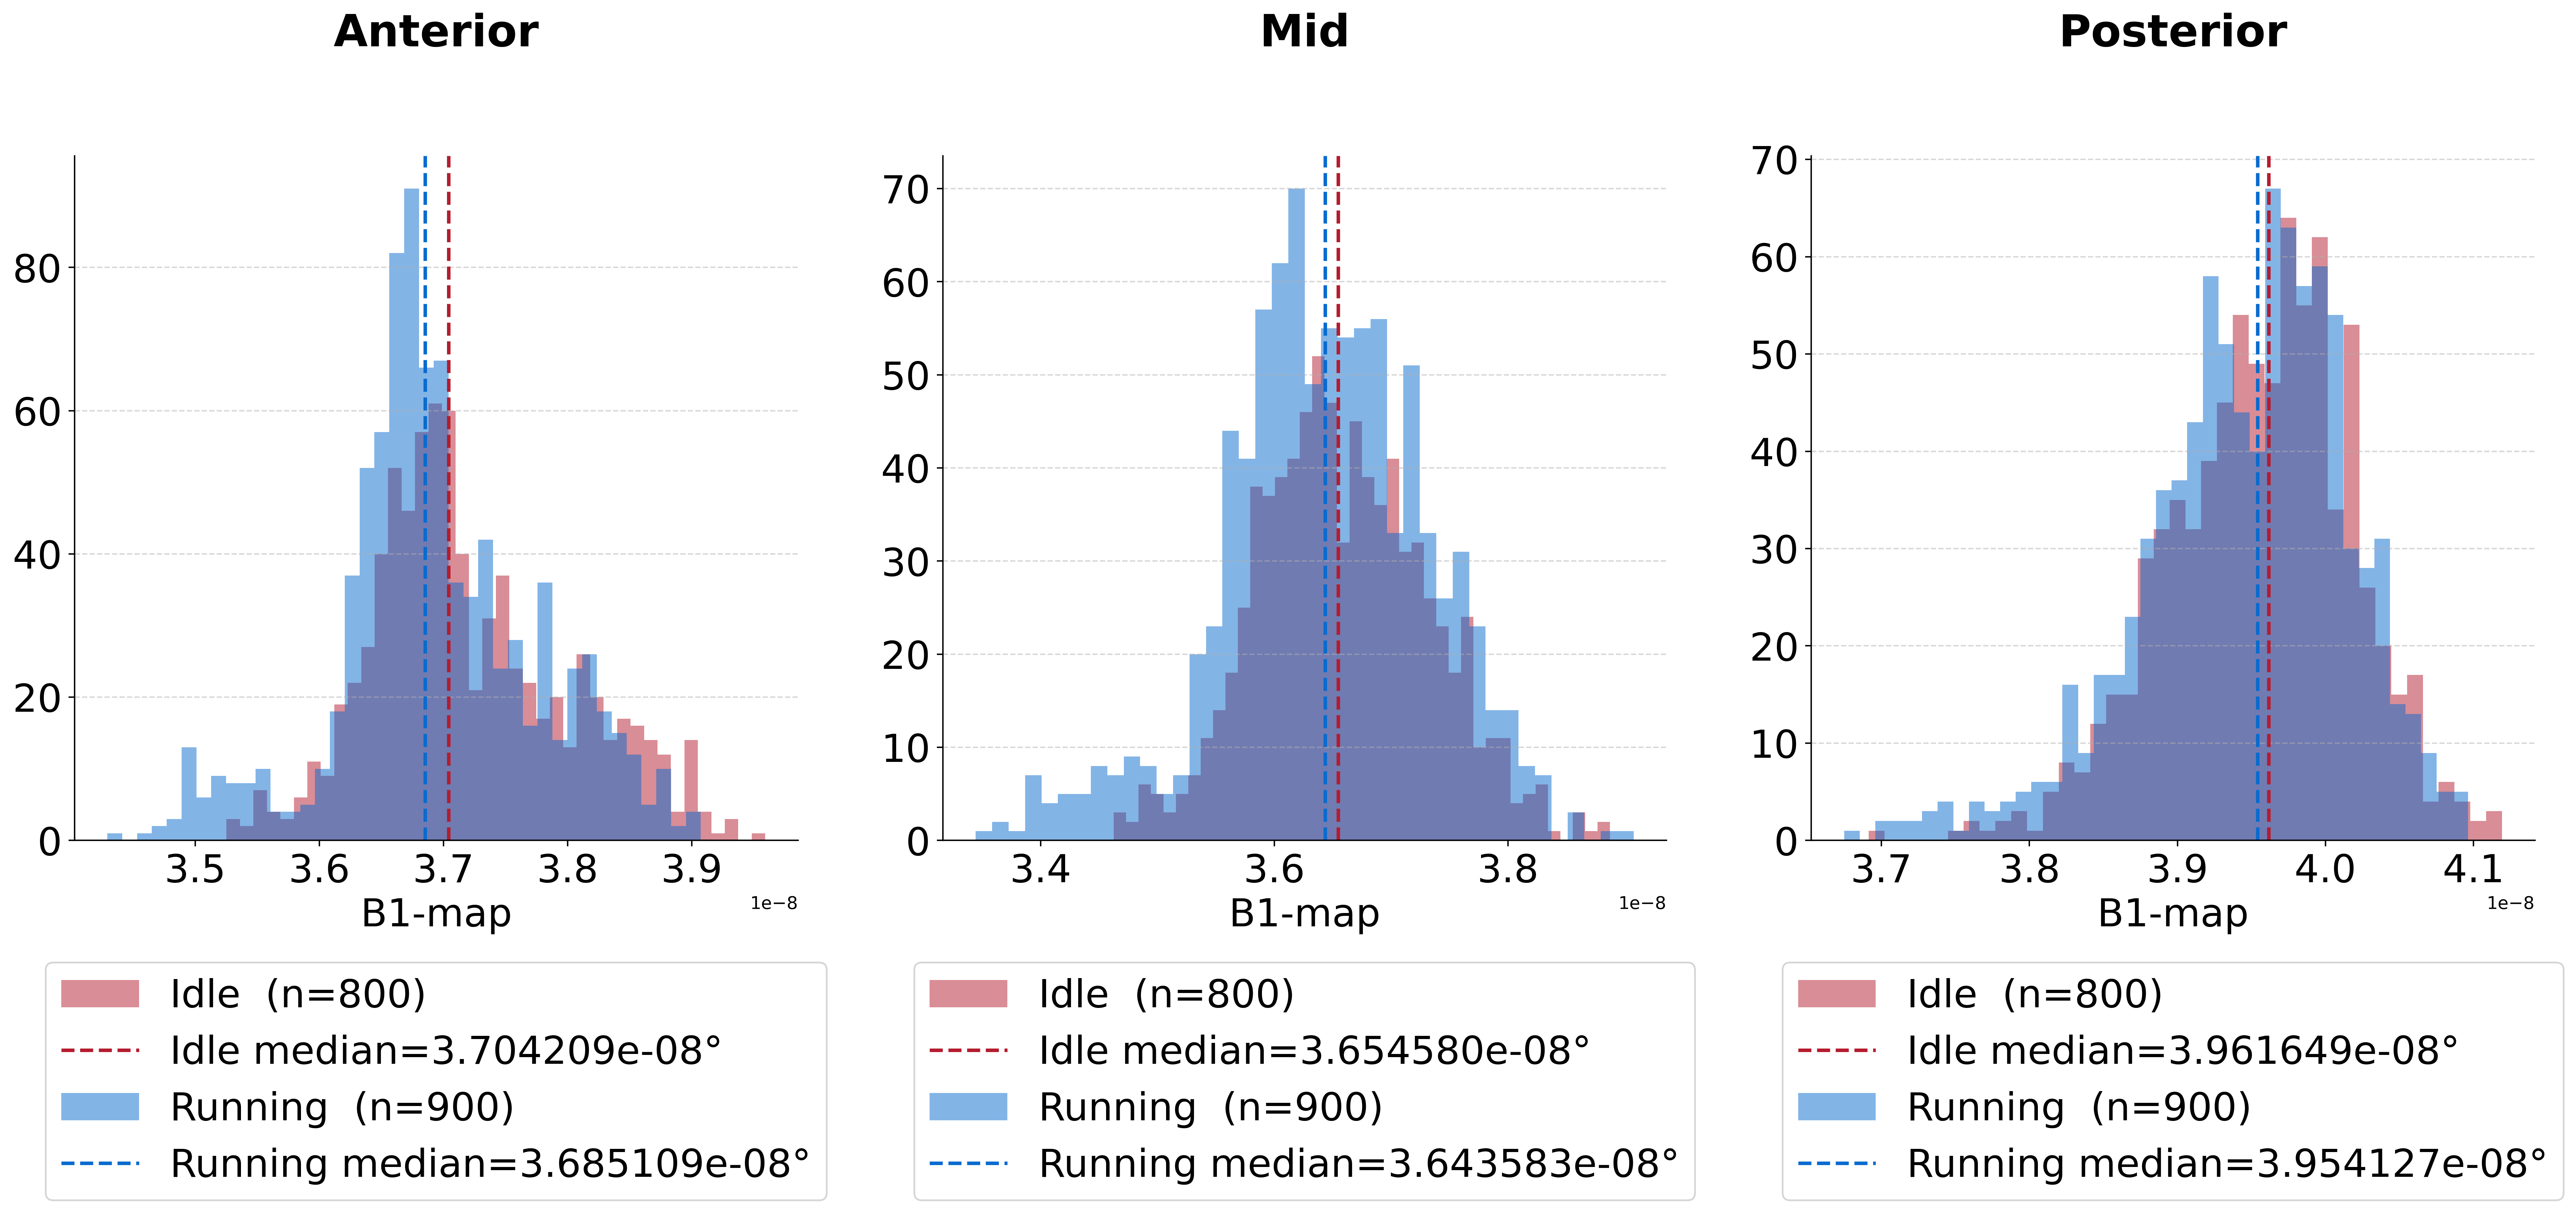

In [ ]:
from collections import defaultdict
import glob, re, os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
from scipy import stats


# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
AXES="tra"

REGIONS = {
    "Anterior":  "tfl-cor_MASK_anterior",
    "Mid":       "tfl-cor_MASK_mid",
    "Posterior": "tfl-cor_MASK_posterior",
}

REGIONS = {
    "Anterior":  "tfl-tra_MASK_anterior",
    "Mid":       "tfl-tra_MASK_mid",
    "Posterior": "tfl-tra_MASK_posterior",
}


REGION_COLORS = {
    "Anterior":  {"Asterix_c": "#058E4A", "Asterix_w": "#43C57E"},
    "Mid":       {"Asterix_c": "#B51C2E", "Asterix_w": "#E6906C"},
    "Posterior": {"Asterix_c": "#086BCF", "Asterix_w": "#6ABAE2"},
}


# ─────────────────────────────────────────────────────────────────
# COLLECT — stack all voxels per condition × ROI
# ─────────────────────────────────────────────────────────────────
all_voxels = {
    region: {"Asterix_c": [], "Asterix_w": []}
    for region in REGIONS
}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses = subjid.split("_", 1)
        base = os.path.join(home, "derivatives", pid, ses, "twix")

        alpha_files = sorted(glob.glob(
            os.path.join(base, f"{subjid}_tfl_map-{AXES}_*b1.nii*")
        ))
        alpha_files = [
            f for f in alpha_files
            if "_MASK" not in os.path.basename(f)
            and (m := re.search(r"_(\d+(?:[p\.]\d+)?)_b1", os.path.basename(f)))
            and float(m.group(1).replace("p", ".")) > 280
        ]

        if len(alpha_files) == 0:
            print(f"[SKIP] no valid alpha files for {subjid}")
            continue

        for map_IMG in alpha_files:
            img  = nib.load(map_IMG).get_fdata()
            data = img[:, :, 0] if img.ndim == 3 else img

            for region, mask_stem in REGIONS.items():
                mask_path = os.path.join(base, f"{subjid}_{mask_stem}.nii.gz")
                if not os.path.exists(mask_path):
                    continue
                mask_data = nib.load(mask_path).get_fdata()
                mask_2d   = mask_data[:, :, 0] if mask_data.ndim == 3 else mask_data

                vals = data[mask_2d.astype(bool)]
                vals = vals[(vals > 0) & (vals < 110)]
                all_voxels[region][condition].extend(vals.tolist())

# ─────────────────────────────────────────────────────────────────
# PLOT — 3 panels, 2 overlapping histograms per panel
# ─────────────────────────────────────────────────────────────────
HIST_COLORS = {
    "Asterix_c": ("#B51C2E", "Idle"),
    "Asterix_w": ("#086BCF", "Running"),
}


fig, axes = plt.subplots(1, 3, figsize=(25, 7), dpi=400,
                         facecolor="white")

for ax, region in zip(axes, REGIONS):
    for cond, (col, label) in HIST_COLORS.items():
        vals = np.array(all_voxels[region][cond])
      
        ax.hist(vals, bins=40, color=col, alpha=0.5,
                label=f"{label}  (n={len(vals)})",
                density=False, edgecolor="none")

        
        ax.axvline(np.median(vals), color=col, linewidth=2,
                   linestyle="--", label=f"{label} median={np.median(vals):4e}°")

    # t-test on voxel distributions
    v0 = np.array(all_voxels[region]["Asterix_c"])
    v1 = np.array(all_voxels[region]["Asterix_w"])
    if len(v0) > 1 and len(v1) > 1:
        _, p = stats.ttest_ind(v0, v1, equal_var=True)
        sig     = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        p_label = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.set_title(f"{region}\n\n", fontsize=25,
                     fontweight="bold")
    else:
        ax.set_title(region, fontsize=30, fontweight="bold")

    ax.set_xlabel("B1-map", fontsize=22)
    ax.set_ylabel("",        fontsize=20)
    ax.tick_params(labelsize=22)
    ax.legend(fontsize=22, loc='upper center', bbox_to_anchor=(0.5, -0.15))
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
AXES = "tra"

REGIONS = {
    "Anterior":  "tfl-tra_MASK_anterior",
    "Mid":       "tfl-tra_MASK_mid",
    "Posterior": "tfl-tra_MASK_posterior",
}


# ─────────────────────────────────────────────────────────────────
# COLLECT — subject-level means (required for mixed ANOVA)
#           + all voxels pooled (for histograms)
# ─────────────────────────────────────────────────────────────────
rows       = []   # one row per subject × region  → ANOVA
all_voxels = {region: {"Asterix_c": [], "Asterix_w": []} for region in REGIONS}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses = subjid.split("_", 1)
        base = os.path.join(home, "derivatives", pid, ses, "twix")

        alpha_files = sorted(glob.glob(
            os.path.join(base, f"{subjid}_tfl_map-{AXES}_*b1.nii*")
        ))
        alpha_files = [
            f for f in alpha_files
            if "_MASK" not in os.path.basename(f)
            and (m := re.search(r"_(\d+(?:[p\.]\d+)?)_b1", os.path.basename(f)))
            and float(m.group(1).replace("p", ".")) > 280
        ]

        if not alpha_files:
            print(f"[SKIP] no valid alpha files for {subjid}")
            continue

        for map_IMG in alpha_files:
            img  = nib.load(map_IMG).get_fdata()
            data = img[:, :, 0] if img.ndim == 3 else img

            for region, mask_stem in REGIONS.items():
                mask_path = os.path.join(base, f"{subjid}_{mask_stem}_b1.nii.gz")

                mask_data = nib.load(mask_path).get_fdata()
                mask_2d   = mask_data[:, :, 0] if mask_data.ndim == 3 else mask_data

                vals = data[mask_2d.astype(bool)]

                # subject-level mean for ANOVA
                rows.append({
                    "subject":   pid,          # ← group by anatomical subject
                    "condition": condition,
                    "region":    region,
                    "b1_mean":   float(np.mean(vals)),
                })

                # pooled voxels for histogram
                all_voxels[region][condition].extend(vals.tolist())

# ─────────────────────────────────────────────────────────────────
# MIXED ANOVA  (condition=between, region=within)
# ─────────────────────────────────────────────────────────────────
df = (
    pd.DataFrame(rows)
    .groupby(["subject", "condition", "region"], as_index=False)["b1_mean"]
    .mean()                              # average across files if >1 per subject
)

print(f"\nSubjects: {df['subject'].nunique()}")
print(df.groupby(["condition", "region"])["subject"].count().to_string())

aov = pg.mixed_anova(
    data      = df,
     dv        = "b1_mean",
    within    = "region",
    between   = "condition",
    subject   = "subject",
    correction= True,
)
print("\n── Mixed ANOVA ──────────────────────────────")
print(aov.to_string(index=False))


## PLOTs HISTs of deltaB0 map
----------------------------
B0s are a bit different, start computing them as masks

In [ ]:
import os
import subprocess
import numpy as np
import nibabel as nib
import glob

# ===========================================================================
# CONFIGURATION
# ===========================================================================
DEFAULT_CUBE_SIZE = (12, 12, 12)
DEFAULT_OFFSETS   = {
    "ant":  {"dx": 0, "dy": 0, "dz": 0}, # dx --> right # dz -->Neg move down
    "mid":  {"dx": 0, "dy": 0, "dz": 0},
    "post": {"dx": 0, "dy": 0, "dz": 0},
}


# ===========================================================================
# HELPERS
# ===========================================================================
def save_nifti(data, affine, header, path):
    img = nib.Nifti1Image(data.astype(np.uint8), affine, header)
    img.set_qform(affine, code=1)
    img.set_sform(affine, code=1)
    nib.save(img, path)


def build_masks(mask, offsets, cube_size):
    assert mask.ndim == 3, f"Expected 3D mask, got shape {mask.shape}"

    X, Y, Z = mask.shape
    px, py, pz = cube_size

    # With a clean (64,64,64) 1mm affine, use geometric center
    # but also compute brain centroid for comparison
    brain_voxels = np.argwhere(mask > 0)
    if len(brain_voxels) == 0:
        # Fallback: pure geometric center
        cx, cy, cz = X // 2, Y // 2, Z // 2
        print(f"  WARNING: empty mask — using geometric center")
    else:
        cx, cy, cz = np.round(brain_voxels.mean(axis=0)).astype(int)
    
    print(f"  Mask voxels: {len(brain_voxels)}  |  centroid: x={cx} y={cy} z={cz}")

    x_center = cx - px // 2 
    y_center = cy - py // 2 
    z_center = cz - pz // 2

    starts = {
        "ant":  (x_center + offsets["ant"]["dx"],  y_center + 13 + offsets["ant"]["dy"],  z_center + 11 + offsets["ant"]["dz"]), # orange
        "mid":  (x_center + offsets["mid"]["dx"],  y_center - 3 + offsets["mid"]["dy"],  z_center -8 + offsets["mid"]["dz"]),
        "post": (x_center + offsets["post"]["dx"], y_center - 17  + offsets["post"]["dy"], z_center + 17 + offsets["post"]["dz"]), 
    }

    masks = {}
    for name, (xs, ys, zs) in starts.items():
        roi = np.zeros_like(mask, dtype=np.uint8)
        xs = max(0, min(xs, X - px))
        ys = max(0, min(ys, Y - py))
        zs = max(0, min(zs, Z - pz))
        roi[xs:xs + px, ys:ys + py, zs:zs + pz] = 1
        masks[name] = roi

    return masks, starts

def save_tmp_masks(masks, affine, header, tmp_dir):
    os.makedirs(tmp_dir, exist_ok=True)
    paths = {}
    for key, arr in masks.items():
        path = os.path.join(tmp_dir, f"_tmp_cube_{key}.nii.gz")
        save_nifti(arr, affine, header, path)
        paths[key] = path
    return paths


def open_fsleyes(map_IMG, mask_paths):
    cmd = [
        "fsleyes",
        map_IMG,            "-cm", "greyscale",
        mask_paths["ant"],  "-cm", "copper",
        mask_paths["mid"],  "-cm", "red-yellow",
        mask_paths["post"], "-cm", "cool",
    ]
    print("\n  Opening FSLeyes … close the window when done.\n")
    subprocess.run(cmd)


# ===========================================================================
# MAIN LOOP
# ===========================================================================
label_map = {"ant": "anterior", "mid": "mid", "post": "posterior"}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses = subjid.split("_", 1)
        base    = os.path.join(home, "derivatives", pid, ses, "twix")
        tmp_dir = os.path.join(base, "tmp")
        os.makedirs(base,    exist_ok=True)
        os.makedirs(tmp_dir, exist_ok=True)

        alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_field_mapping_*_dB0_clean.nii")))

        if len(alpha_files) == 0:
            print(f"WARNING: no field_mapping dB0 files for {subjid}")
            continue

        for map_IMG in alpha_files:
            print(f"\nProcessing: {map_IMG}")

            img    = nib.load(map_IMG)
            data   = img.get_fdata()
            affine = img.affine.copy()
            header = img.header.copy()

            if data.ndim != 3:
                print(f"  SKIP: expected 3D volume, got shape {data.shape}")
                continue

            print(f"  Volume shape: {data.shape}")

            mask = (~np.isfinite(data)).astype(np.uint8)

            # quick sanity check
            brain_voxels = np.argwhere(mask > 0)
            cx, cy, cz = np.round(brain_voxels.mean(axis=0)).astype(int)
            print(f"  Brain centroid: x={cx}  y={cy}  z={cz}")

            offsets   = {k: dict(v) for k, v in DEFAULT_OFFSETS.items()}
            cube_size = DEFAULT_CUBE_SIZE
            approved  = False

            print(f"\n{'='*60}")
            print(f"  Subject: {subjid}")
            print(f"{'='*60}")

            while not approved:
                masks, starts = build_masks(mask, offsets, cube_size)
                mask_paths    = save_tmp_masks(masks, affine, header, tmp_dir)

                print("\n  Current ROI starts (voxel coords):")
                for roi, s in starts.items():
                    print(f"    {roi:4s}  x={s[0]:4d}  y={s[1]:4d}  z={s[2]:4d}")

                open_fsleyes(map_IMG, mask_paths)

                resp = input("\n  Approve these ROIs? [y] / adjust [n]: ").strip().lower()
                if resp in ("", "y", "yes"):
                    approved = True
                else:
                    print("  Enter new offsets (leave blank to keep current):")
                    for region in ("ant", "mid", "post"):
                        for axis in ("dx", "dy", "dz"):
                            val = input(f"    {region} {axis} [{offsets[region][axis]}]: ").strip()
                            if val:
                                offsets[region][axis] = int(val)

            # Save final masks
            for key, arr in masks.items():
                fname = f"{subjid}_field_mapping_MASK_{label_map[key]}_dB0.nii.gz"
                save_nifti(arr, affine, header, os.path.join(base, fname))
                print(f"  Saved → {fname}")

    
            print(f"\n  ✓ {subjid} done.\n")

In [381]:
## MIXED ANOVA 

# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
AXES = "tra"

REGIONS = {
    "Anterior":  "field_mapping_MASK_anterior",
    "Mid":       "field_mapping_MASK_mid",
    "Posterior": "field_mapping_MASK_posterior",
}


# ─────────────────────────────────────────────────────────────────
# COLLECT — subject-level means (required for mixed ANOVA)
#           + all voxels pooled (for histograms)
# ─────────────────────────────────────────────────────────────────
rows       = []   # one row per subject × region  → ANOVA
all_voxels = {region: {"Asterix_c": [], "Asterix_w": []} for region in REGIONS}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses = subjid.split("_", 1)
        base = os.path.join(home, "derivatives", pid, ses, "twix")

        alpha_files = sorted(glob.glob(os.path.join(base, f"{subjid}_field_mapping_*_dB0_clean.nii"))) #Trasmit eff. map _field_mapping_*_dB0.nii
      
        alpha_files = [
            f for f in alpha_files
            if "_MASK" not in os.path.basename(f)
            and (m := re.search(r"_(\d+(?:[p\.]\d+)?)_dB0", os.path.basename(f)))
            and float(m.group(1).replace("p", ".")) > 280
        ]

        for map_IMG in alpha_files:
            img  = nib.load(map_IMG).get_fdata()

            for region, mask_stem in REGIONS.items():
                mask_path = os.path.join(base, f"{subjid}_{mask_stem}_dB0.nii.gz")
                
                if not os.path.exists(mask_path):
                    print(f"[SKIP] missing mask: {mask_path}")
                    continue

                mask      = nib.load(mask_path).get_fdata().astype(bool)
                vals      = img[mask]
                vals      = vals[~np.isnan(vals)]
                
                if len(vals) == 0:
                    print(f"[SKIP] empty ROI: {subjid} | {region}")
                    continue

                # subject-level mean for ANOVA
                rows.append({
                    "subject":   pid,          # ← group by anatomical subject
                    "condition": condition,
                    "region":    region,
                    "b0_mean":   float(np.mean(vals)),
                })

                print(f"{pid}: {float(np.mean(vals))} ")

                # pooled voxels for histogram
                all_voxels[region][condition].extend(vals.tolist())

# ─────────────────────────────────────────────────────────────────
# MIXED ANOVA  (condition=between, region=within)
# ─────────────────────────────────────────────────────────────────
df = (
    pd.DataFrame(rows)
    .groupby(["subject", "condition", "region"], as_index=False)["b0_mean"]
    .mean()                              # average across files if >1 per subject 
)

print(f"\nSubjects: {df['subject'].nunique()}")
print(df.groupby(["condition", "region"])["subject"].count().to_string())

aov = pg.mixed_anova(
    data      = df,
    dv        = "b0_mean",
    within    = "region",
    between   = "condition",
    subject   = "subject",
    correction= True,
)
print("\n── Mixed ANOVA ──────────────────────────────")
print(aov.to_string(index=False))


sub-16: 13.92027969249682 
sub-16: 5.477421192445559 
sub-16: -0.5700477720186196 
sub-17: 13.387687108643672 
sub-17: 5.566543704732637 
sub-17: -0.8801877849467311 
sub-20: 14.224516492995399 
sub-20: 6.039080864905473 
sub-20: -0.19918992580441464 
sub-21: 15.024631293450348 
sub-21: 7.325196392222354 
sub-21: 0.6802467677039133 
sub-25: 14.871568847157517 
sub-25: 6.919855833963795 
sub-25: 0.5881752688257765 
sub-26: 13.36326649005207 
sub-26: 5.248521795327023 
sub-26: -1.1796155313690053 
sub-29: 13.826429382598361 
sub-29: 5.670605466056181 
sub-29: -0.9616909865939731 
sub-30: 13.851552256712163 
sub-30: 5.7512792111179545 
sub-30: -0.737457126131051 
sub-32: 13.59753029328862 
sub-32: 5.4686067425157585 
sub-32: -0.9765360690972884 
sub-19: 14.185279294827488 
sub-19: 6.368185916485688 
sub-19: -0.7355409125751464 
sub-18: 14.81798565740027 
sub-18: 7.251530247620946 
sub-18: -0.4873313269570167 
sub-15: 13.246905151116161 
sub-15: 5.345326051283503 
sub-15: -2.27645013212939

In [ ]:
import pingouin as pg

print("\n── POST-HOC: Condition effect within each ROI ──")

for roi in df["region"].unique():

    sub = df[df["region"] == roi]

    t = pg.ttest(
        sub[sub["condition"] == "Asterix_c"]["b0_mean"],
        sub[sub["condition"] == "Asterix_w"]["b0_mean"],
        paired=False
    )

    print(f"\nROI: {roi}")
    print(t[["T", "dof", "p-val", "cohen-d"]])

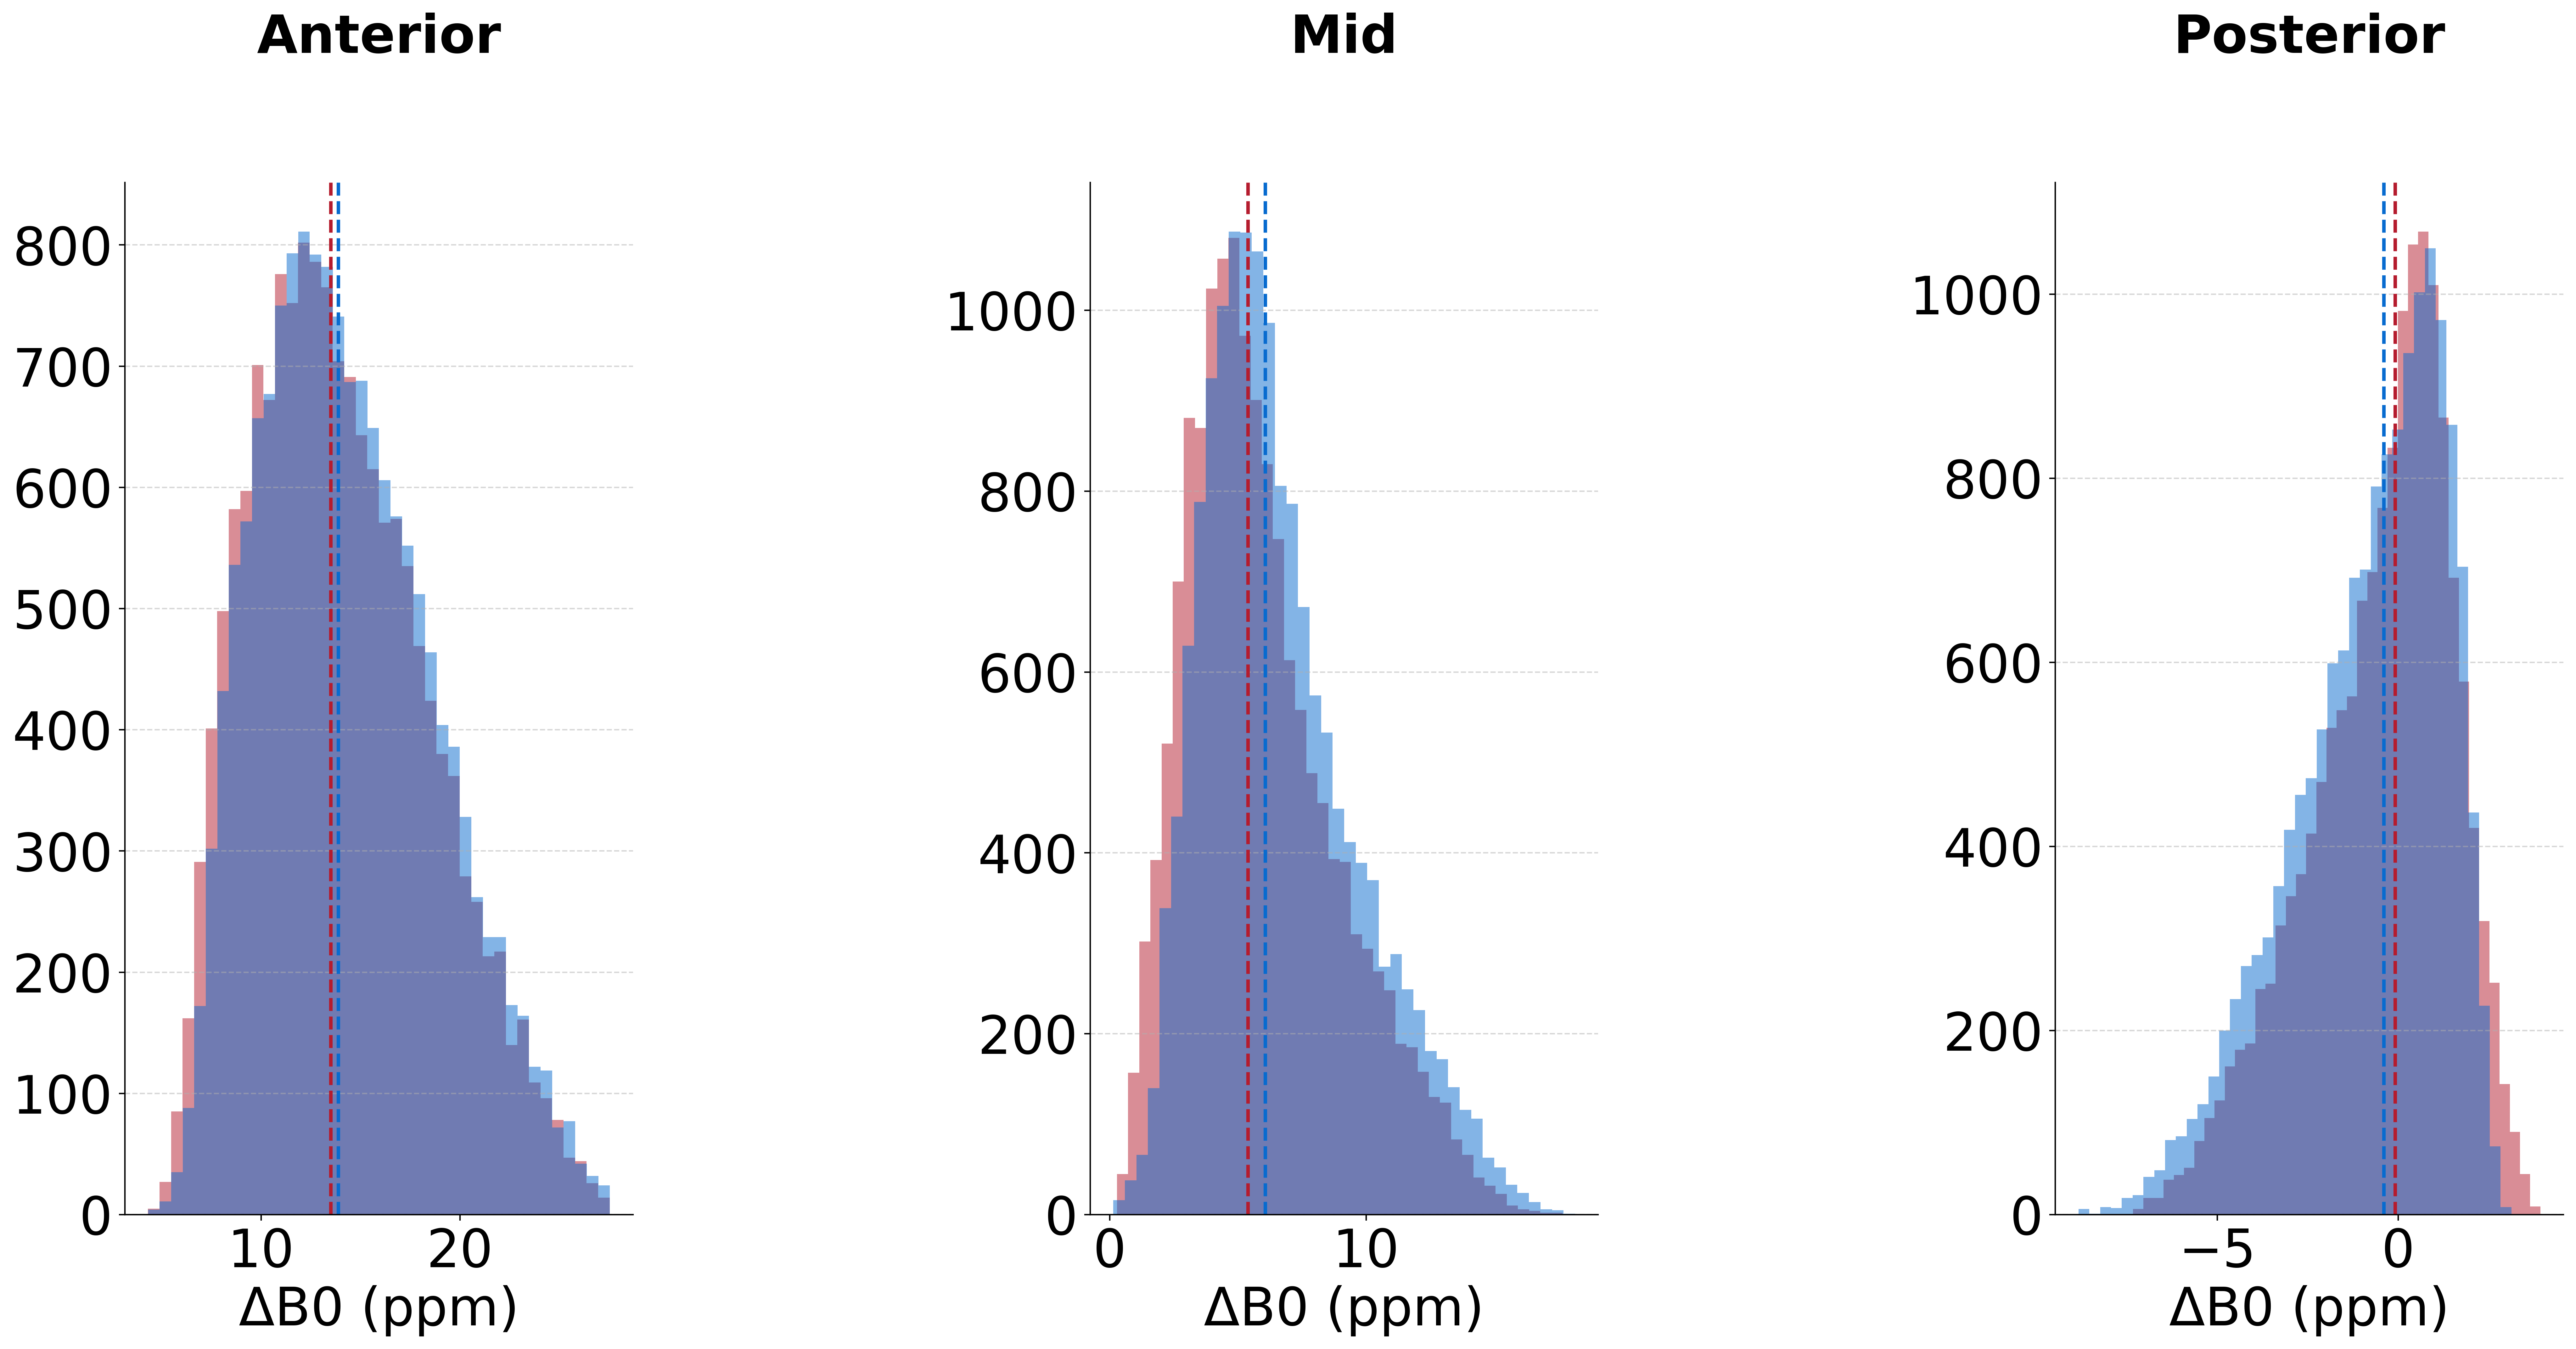

In [389]:
# ─────────────────────────────────────────────────────────────────
# PLOT — 3 histogram panels (dB0 maps)
# ─────────────────────────────────────────────────────────────────
HIST_COLORS = {
    "Asterix_c": ("#B51C2E", "Idle"),
    "Asterix_w": ("#086BCF", "Running"),
}


def stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return "ns"

fig, axes = plt.subplots(1, 3, figsize=(25, 10), dpi=400, facecolor="white")



for ax, region in zip(axes, REGIONS):

    # ── post-hoc t-test on subject means ─────────────────────────
    grp    = df[df["region"] == region]
    c_vals = grp.loc[grp["condition"] == "Asterix_c", "b0_mean"].values
    w_vals = grp.loc[grp["condition"] == "Asterix_w", "b0_mean"].values
    if len(c_vals) > 1 and len(w_vals) > 1:
        _, p_post = stats.ttest_ind(c_vals, w_vals, equal_var=False)
    else:
        p_post = 1.0
    p_str = "p < 0.001" if p_post < 0.001 else f"p = {p_post:.3f}"

    for cond, (col, label) in HIST_COLORS.items():
        vals = np.array(all_voxels[region][cond])
        if len(vals) == 0:
            continue

        ax.hist(vals, bins=40, color=col, alpha=0.5,
                label=f"{label}",
                density=False, edgecolor="none")

        ax.axvline(np.median(vals), color=col, linewidth=2, linestyle="--",
                   label=f"median = {np.median(vals):.2f} ppm")

    ax.set_title(
        f"{region}\n\n",
        fontsize=30, fontweight="bold"
    )
    ax.set_xlabel("ΔB0 (ppm)",  fontsize=30)
    ax.set_ylabel("", fontsize=30)
    ax.tick_params(labelsize=30)
  #  ax.legend(fontsize=30, loc="upper center", bbox_to_anchor=(0.5, -0.25),  frameon=False)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.subplots_adjust(top=0.93, hspace=0.55, wspace=0.9)
plt.show()

## PLOTS HISTs of b=1000/b=0

In [5]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats

# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
B0_THRESH  = 50
B1000_LOW  = 800
B1000_HIGH = 1200

REGIONS = {
    "Anterior":  "cube_mask_dMRI-space-anterior",
    "Mid":       "cube_mask_dMRI-space-mid",
    "Posterior": "cube_mask_dMRI-space-posterior",
}

CONDITIONS = {
    "Asterix_c": {"label": "Idle",    "color": "#B51C2E"},
    "Asterix_w": {"label": "Running", "color": "#086BCF"},
}


def parse_bvals(bval_path):
    with open(bval_path) as f:
        return np.array([float(x) for x in f.read().split()])


# ─────────────────────────────────────────────────────────────────
# 1. COLLECT
# ─────────────────────────────────────────────────────────────────
all_voxels = {
    shell: {region: {"Asterix_c": [], "Asterix_w": []} for region in REGIONS}
    for shell in ["b0", "b1000"]
}

for condition, subjects in Asterix.items():
    for subjid in subjects:
        pid, ses  = subjid.split("_", 1)
        base = os.path.join(home, "derivatives", pid, ses, "dwi")
        eddy_path = os.path.join(base, "eddy")
        prep_path = os.path.join(base, "prep")
        masks_dir = os.path.join(base, "masks")

        dwi_path  = os.path.join(eddy_path, f"{subjid}_eddy_corrected.nii")
        bval_path = os.path.join(prep_path,  f"{subjid}_dir-PA-AP_part-mag_dwi.bval")

        if not os.path.exists(dwi_path) or not os.path.exists(bval_path):
            print(f"[SKIP] {subjid} — DWI or bval missing")
            continue

        bvals = parse_bvals(bval_path)
        img   = nib.load(dwi_path)
        data  = img.get_fdata(dtype=np.float32)

        shells = {
            "b0":    np.where((bvals >= 0)        & (bvals <= B0_THRESH))[0],
            "b1000": np.where((bvals >= B1000_LOW) & (bvals <= B1000_HIGH))[0],
        }

        for shell_name, idx in shells.items():
            if len(idx) == 0:
                print(f"[WARN] {subjid} — no volumes for {shell_name}")
                continue

            mean_vol = data[..., idx].mean(axis=-1)

            for region, mask_stem in REGIONS.items():
                mask_path = os.path.join(masks_dir, f"{subjid}_{mask_stem}.nii.gz")
                if not os.path.exists(mask_path):
                    continue

                mask = nib.load(mask_path).get_fdata() > 0
                vals = mean_vol[mask].ravel()
                vals = vals[vals > 0]
                all_voxels[shell_name][region][condition].extend(vals.tolist())

for shell in all_voxels:
    for region in all_voxels[shell]:
        for cond in all_voxels[shell][region]:
            all_voxels[shell][region][cond] = np.array(all_voxels[shell][region][cond])


In [6]:
import pandas as pd
import numpy as np
import os
import nibabel as nib
import pingouin as pg

# ─────────────────────────────────────────────────────────────────
# SUBJECT-LEVEL COLLECTION (FIXED FOR MIXED ANOVA)
# ─────────────────────────────────────────────────────────────────

rows = []

for condition, subjects in Asterix.items():

    for subjid in subjects:

        pid, ses = subjid.split("_", 1)

        base = os.path.join(home, "derivatives", pid, ses, "dwi")
        eddy_path = os.path.join(base, "eddy")
        prep_path = os.path.join(base, "prep")
        masks_dir = os.path.join(base, "masks")

        dwi_path  = os.path.join(eddy_path, f"{subjid}_eddy_corrected.nii")
        bval_path = os.path.join(prep_path, f"{subjid}_dir-PA-AP_part-mag_dwi.bval")

        bvals = parse_bvals(bval_path)
        img   = nib.load(dwi_path)
        data  = img.get_fdata(dtype=np.float32)

        shells = {
            "b0": np.where((bvals >= 0) & (bvals <= B0_THRESH))[0],
            "b1000": np.where((bvals >= B1000_LOW) & (bvals <= B1000_HIGH))[0],
        }

        for shell_name, idx in shells.items():

            mean_vol = data[..., idx].mean(axis=-1)

            for region, mask_stem in REGIONS.items():

                mask_path = os.path.join(masks_dir, f"{subjid}_{mask_stem}.nii.gz")
                if not os.path.exists(mask_path):
                    continue

                mask = nib.load(mask_path).get_fdata() > 0

                vals = mean_vol[mask]
                vals = vals[vals > 0]

                subj_mean = np.mean(vals)

                rows.append({
                    "subject": subjid,
                    "condition": condition,
                    "region": region,
                    "shell": shell_name,
                    "intensity": subj_mean
                })

df = pd.DataFrame(rows)


for shell in ["b0", "b1000"]:

    sub_df = df[df["shell"] == shell]

    aov = pg.mixed_anova(
        data=sub_df,
        dv="intensity",
        within="region",
        between="condition",
        subject="subject",
        correction=True
    )

    print(aov)

        Source            SS  DF1  DF2            MS           F  \
0    condition  2.663022e+02    1   16  2.663022e+02    0.003108   
1       region  6.633201e+06    2   32  3.316600e+06  586.920865   
2  Interaction  3.615999e+03    2   32  1.808000e+03    0.319952   

          p_unc     p_GG_corr       np2       eps sphericity   W_spher  \
0  9.562342e-01           NaN  0.000194       NaN        NaN       NaN   
1  6.049991e-26  1.187195e-17  0.973463  0.614136      False  0.371696   
2  7.284802e-01           NaN  0.019605       NaN        NaN       NaN   

    p_spher  
0       NaN  
1  0.000364  
2       NaN  
        Source             SS  DF1  DF2            MS            F  \
0    condition    2623.024910    1   16   2623.024910     0.863099   
1       region  191914.220884    2   32  95957.110442  1172.911713   
2  Interaction       3.984674    2   32      1.992337     0.024353   

          p_unc     p_GG_corr       np2       eps sphericity   W_spher  \
0  3.666778e-01    

In [7]:
for shell in ["b0", "b1000"]:
    fig, axes = plt.subplots(1, 3, figsize=(25, 10), dpi=600, facecolor="white")
    fig.suptitle(
        f"",
        fontsize=24, fontweight="bold", y=1.05
    )

    for col, region in enumerate(REGIONS):
        ax = axes[col]

        for cond, info in CONDITIONS.items():
            vals = all_voxels[shell][region][cond]
            ax.hist(vals, bins=80, color=info["color"], alpha=0.55,
                    density=False, edgecolor="none",
                    label=f"{info['label']}")
            ax.axvline(np.median(vals), color=info["color"], lw=2, ls="--")

        # t-test
        v0 = all_voxels[shell][region]["Asterix_c"]
        v1 = all_voxels[shell][region]["Asterix_w"]
        if len(v0) > 1 and len(v1) > 1:
            _, p  = stats.ttest_ind(v0, v1, equal_var=False)
            sig   = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
            p_str = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        else:
            sig, p_str = "—", "—"

        ax.set_title(f"{region}\n\n", fontsize=30, fontweight="bold", pad=10)
        ax.set_xlabel(f"Signal Intensity \n", fontsize=30, labelpad=10)
        ax.set_ylabel("", fontsize=30, labelpad=10)
        ax.tick_params(axis='y', labelsize=30)
        ax.tick_params(axis='x', labelsize=25)

        ax.grid(True, axis="y", linestyle="--", alpha=0.4)
        ax.spines[["top", "right"]].set_visible(False)

        from matplotlib.lines import Line2D
    
       
        handles, labels = ax.get_legend_handles_labels()

        line_handles = [
            Line2D([0], [0], color=info["color"], lw=2, ls="--")
            for info in CONDITIONS.values()
        ]

        idle_handles    = [handles[0], line_handles[0]]
        idle_labels     = [labels[0],  "Idle median"]

        running_handles = [handles[1], line_handles[1]]
        running_labels  = [labels[1],  " Running median "]

        leg1 = ax.legend(idle_handles, idle_labels,
                        fontsize=28,
                        loc="upper left",
                        bbox_to_anchor=(0.0, -0.2),   # left-aligned under subplot
                        ncol=1,
                        frameon=False)
        ax.add_artist(leg1)

        leg2 = ax.legend(running_handles, running_labels,
                        fontsize=28,
                        loc="upper right",
                        bbox_to_anchor=(1.4, -0.4),   # right-aligned under subplot
                        ncol=1,
                        frameon=False)
               
    
    plt.subplots_adjust(top=0.93, bottom=0.28, hspace=0.85, wspace=0.5)
    plt.show()
